# Apéndice — LSTM unidireccional vs. BiLSTM (features handcrafted)

Ablación de la **direccionalidad** del modelo secuencial tabular. Se compara el **BiLSTM**
ya entrenado (`../../models/best_lstm.pt`, el modelo principal de `model.ipynb`) contra una
**LSTM unidireccional** idéntica en todo salvo `bidirectional=False`.

Para que la comparación sea limpia, la LSTM unidireccional:

- usa **exactamente los mismos hiperparámetros** que el BiLSTM (los mejores del *bayesian
  search* de Optuna, `models/searchs/lstm.csv` / `lstm.db`): `hidden_size`, `num_layers`,
  `dropout`, `lr`, `weight_decay`, `batch_size`;
- se entrena **exactamente igual** (`train_final`: fase 1 con val para fijar el presupuesto de
  epochs + fase 2 refit sobre train+val), sobre el **mismo split por sujeto** (misma seed);
- solo cambia `bidirectional=True → False`.

Luego se reportan **todas las métricas** para ambos modelos, en **5 clases** (Wake/N1/N2/N3/REM)
y **4 clases** (Wake/Light/Deep/REM), sobre el mismo test set.

In [1]:
import os
import sys
from dataclasses import replace
from pathlib import Path

sys.path.append("../..")  # notebook de appendices -> raíz del proyecto

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import src.tuning as tuning
from src.lstm import (ConfigLSTM, train_final, evaluate, plot_history,
                      STAGE_NAMES, COLLAPSE_4_NAMES, collapse4_labels, collapse4_scores)
from src.tuning import best_config
from src.metrics import print_metrics, plot_confusion, roc_pr_curves

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuraciones

Ambos modelos parten de la **misma** `ConfigLSTM` con los mejores hiperparámetros del search
(`best_config` levanta la fila de mayor kappa de val de `lstm.csv`). Como este notebook vive en
`notebooks/appendices/`, las rutas apuntan dos niveles arriba (`../../`) y se ajusta
`tuning.SEARCH_DIR` para que `best_config` encuentre el CSV del search.

- `cfg_bilstm`: el modelo principal ya entrenado (`best_lstm.pt`), `bidirectional=True`.
- `cfg_uni`: idéntico pero `bidirectional=False` y otro checkpoint (`best_lstm_uni.pt`).

In [2]:
# best_config lee de tuning.SEARCH_DIR; apuntarlo al search real desde appendices/
tuning.SEARCH_DIR = Path("../../models/searchs")

# misma base que model.ipynb (epochs/patience), con rutas ../../ para este notebook
base = ConfigLSTM(hybrid=False,
                  features_path="../../data_extraction/epoch_features.csv",
                  sequences_dir="../../data_extraction/sequences",
                  epochs=60, patience=15)

# mejores hiperparámetros del bayesian search (los mismos con que se entrenó el BiLSTM)
cfg_bilstm = best_config(base, "lstm")
cfg_bilstm = replace(cfg_bilstm, bidirectional=True, ckpt_path="../../models/best_lstm.pt")

# LSTM unidireccional: TODO igual salvo bidirectional=False y su propio checkpoint
cfg_uni = replace(cfg_bilstm, bidirectional=False, ckpt_path="../../models/best_lstm_uni.pt")

print("cfg_bilstm ->", cfg_bilstm)
print("cfg_uni    ->", cfg_uni)

cfg_bilstm -> ConfigLSTM(hybrid=False, features_path='../../data_extraction/epoch_features.csv', sequences_dir='../../data_extraction/sequences', feature_dim=128, hidden_size=128, num_layers=2, dropout=0.3652272824493826, bidirectional=True, batch_size=4, lr=0.0010675227795271, weight_decay=3.8670718114899184e-05, epochs=60, grad_clip=5.0, use_class_weights=True, amp=None, patience=15, refit_trainval=False, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../../models/best_lstm.pt', feature_cols=None, input_size=None)
cfg_uni    -> ConfigLSTM(hybrid=False, features_path='../../data_extraction/epoch_features.csv', sequences_dir='../../data_extraction/sequences', feature_dim=128, hidden_size=128, num_layers=2, dropout=0.3652272824493826, bidirectional=False, batch_size=4, lr=0.0010675227795271, weight_decay=3.8670718114899184e-05, epochs=60, grad_clip=5.0, use_class_weights=True, amp=None, patience=15, refit_trainval=False, val_frac=0.15, test_frac=0.15, seed=36631, d

## 2. Modelos

- **BiLSTM**: se carga el checkpoint ya entrenado (`evaluate`), no se reentrena.
- **LSTM unidireccional**: se entrena con `train_final` (mismo procedimiento en dos fases que el
  BiLSTM). `TRAIN_NEW=False` reusa `best_lstm_uni.pt` si ya existe.

In [3]:
TRAIN_NEW = True  # True: entrena la LSTM unidireccional de cero; False: usa best_lstm_uni.pt si existe

# BiLSTM: ya entrenado -> solo evaluar en test (mismo split guardado en el checkpoint)
model_bi, test_bi = evaluate(cfg_bilstm)
hist_uni = None

cargado ../../models/best_lstm.pt (LSTM tabular, val kappa nan, epoch 23)
TEST -> kappa 0.4630 | macroF1 0.5673 | acc 0.5880


In [4]:
# LSTM unidireccional: entrenar igual que el BiLSTM (train_final) o reusar el checkpoint
if TRAIN_NEW or not os.path.exists(cfg_uni.ckpt_path):
    model_uni, hist_uni, test_uni = train_final(cfg_uni)
else:
    model_uni, test_uni = evaluate(cfg_uni)
    hist_uni = None

Early Stop (LSTM) - epoch 31 (mejor 0.4196 @ 16):  50%|█████     | 30/60 [03:31<03:31,  7.05s/epoch, train_loss=0.7380, val_loss=1.2086, val_kappa=0.4064, best=0.4196]



TEST (LSTM) — mejor ckpt (val kappa 0.4196, epoch 16):
  kappa 0.3979 | macroF1 0.5265 | acc 0.5229
  4-clases: kappa 0.4439 | macroF1 0.6178 | acc 0.6213

[refit LSTM tabular] fase 2: reentreno sobre train+val por 16 epochs (mejor epoch de val en fase 1)


Training (LSTM): 100%|██████████| 16/16 [01:45<00:00,  6.58s/epoch, train_loss=0.9270]



TEST (LSTM) — mejor ckpt (val kappa nan, epoch 16):
  kappa 0.4103 | macroF1 0.5395 | acc 0.5321
  4-clases: kappa 0.4595 | macroF1 0.6354 | acc 0.6317


## 3. Curvas de entrenamiento (LSTM unidireccional)

Curvas train/val de la fase 1 del `train_final` (loss + métricas de validación). El BiLSTM no
tiene `history` acá porque se cargó ya entrenado (sus curvas están en `model.ipynb`).

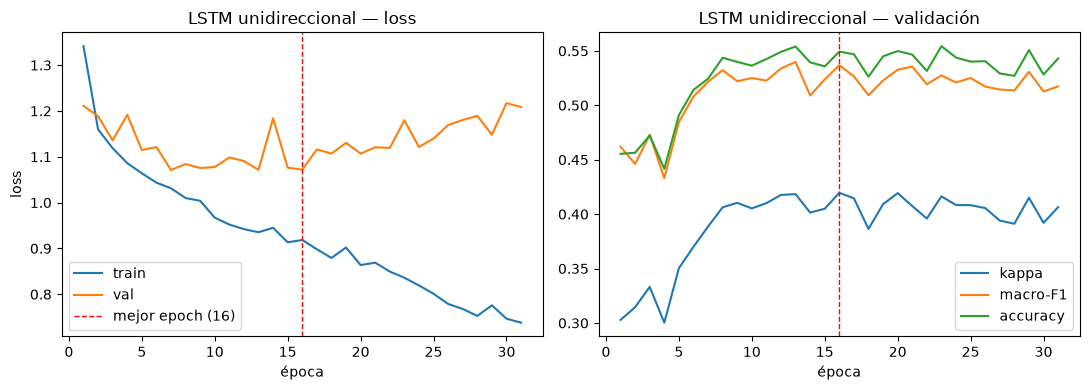

In [5]:
if hist_uni is not None:
    plot_history(hist_uni, title="LSTM unidireccional")
    plt.tight_layout(); plt.show()
else:
    print("LSTM unidireccional: sin history (TRAIN_NEW=False); se omiten las curvas.")

## 4. Comparación de métricas (test, vs Expert)

Tabla resumen para ambos modelos en 5 y 4 clases: Cohen's Kappa, F1 macro, F1 micro y accuracy.

In [6]:
def row(name, tm):
    return {
        "modelo": name,
        "kappa": tm["kappa"], "macroF1": tm["macro_f1"],
        "microF1": tm["micro_f1"], "acc": tm["accuracy"],
        "kappa_4": tm["kappa_4"], "macroF1_4": tm["macro_f1_4"],
        "microF1_4": tm["micro_f1_4"], "acc_4": tm["accuracy_4"],
    }

summary = pd.DataFrame([row("BiLSTM", test_bi), row("LSTM (uni)", test_uni)]).set_index("modelo")
summary.round(4)

,kappa,macroF1,microF1,acc,kappa_4,macroF1_4,microF1_4,acc_4
modelo,,,,,,,,
BiLSTM,0.4630,0.5673,0.5880,0.5880,0.4907,0.6500,0.6519,0.6519
LSTM (uni),0.4103,0.5395,0.5321,0.5321,0.4595,0.6354,0.6317,0.6317


## 5. Métricas detalladas, matrices de confusión y curvas ROC/PR

Para cada modelo y cada vista (5 y 4 clases): `classification_report` + kappa, matriz de
confusión y curvas ROC / Precision-Recall one-vs-rest (mismas funciones de `src/metrics.py` que
el resto de los notebooks). Las vistas de 4 clases se obtienen colapsando etiquetas y
probabilidades (`collapse4_labels` / `collapse4_scores`).


===== BiLSTM — 5 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake     0.7391    0.5790    0.6493      3361
          N1     0.2453    0.3775    0.2974      2776
          N2     0.6974    0.5231    0.5978     11481
          N3     0.6503    0.8261    0.7277      5654
         REM     0.5403    0.5900    0.5641      6222

    accuracy                         0.5880     29494
   macro avg     0.5745    0.5792    0.5673     29494
weighted avg     0.6174    0.5880    0.5932     29494

Cohen's Kappa:  0.4630
F1 macro:       0.5673
F1 micro:       0.5880
Accuracy:       0.5880


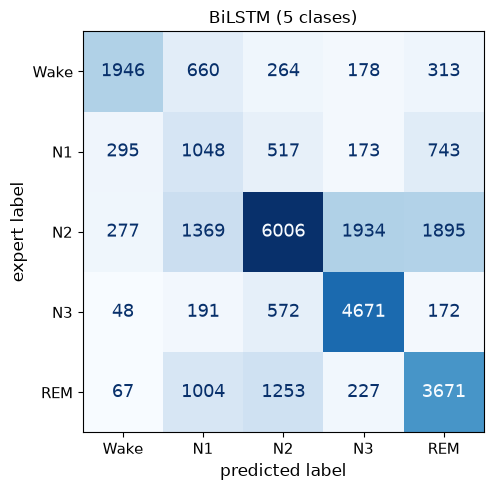

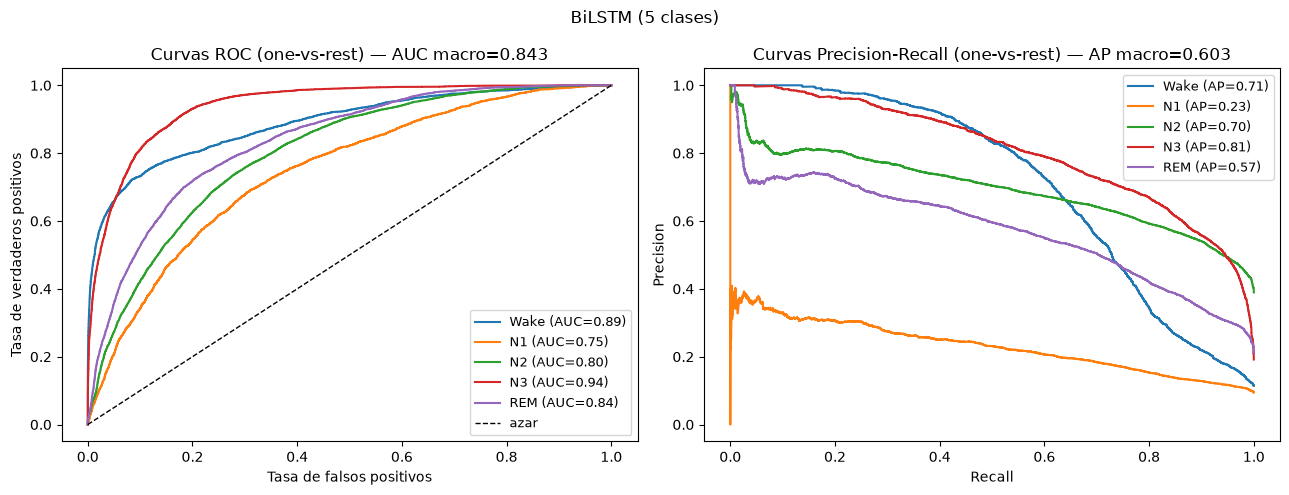


===== BiLSTM — 4 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake     0.7391    0.5790    0.6493      3361
       Light     0.6939    0.6271    0.6588     14257
        Deep     0.6503    0.8261    0.7277      5654
         REM     0.5403    0.5900    0.5641      6222

    accuracy                         0.6519     29494
   macro avg     0.6559    0.6555    0.6500     29494
weighted avg     0.6583    0.6519    0.6509     29494

Cohen's Kappa:  0.4907
F1 macro:       0.6500
F1 micro:       0.6519
Accuracy:       0.6519


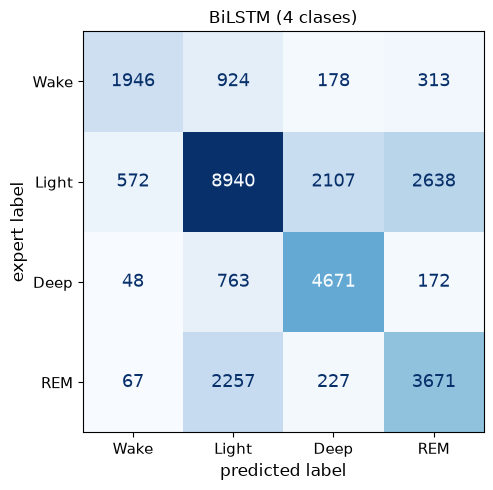

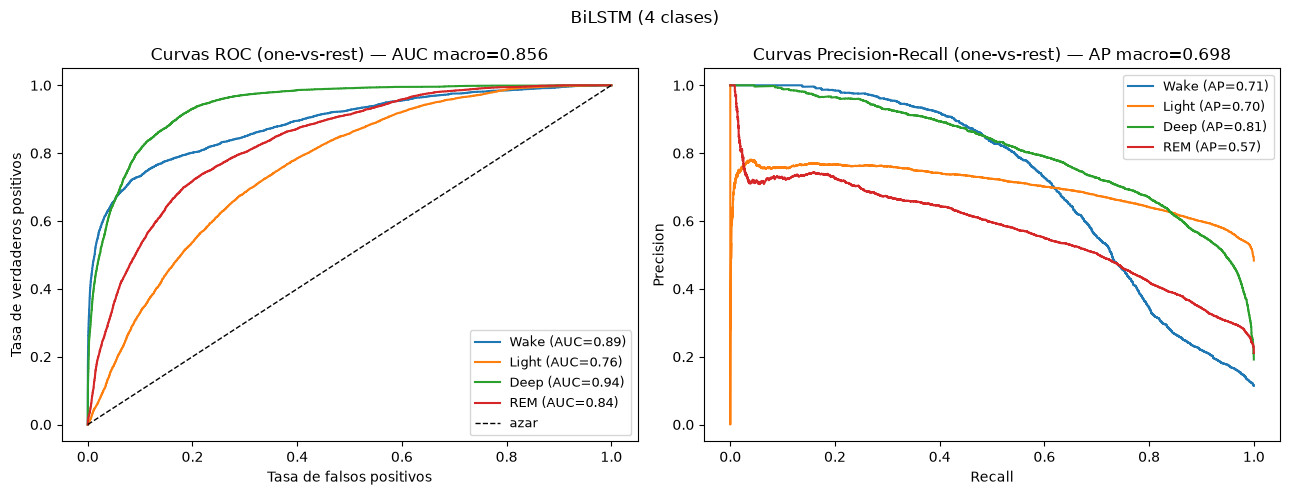


===== LSTM (uni) — 5 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake     0.7250    0.5930    0.6524      3361
          N1     0.2075    0.5249    0.2975      2776
          N2     0.7292    0.3832    0.5023     11481
          N3     0.7082    0.7678    0.7368      5654
         REM     0.4635    0.5633    0.5086      6222

    accuracy                         0.5321     29494
   macro avg     0.5667    0.5664    0.5395     29494
weighted avg     0.6195    0.5321    0.5464     29494

Cohen's Kappa:  0.4103
F1 macro:       0.5395
F1 micro:       0.5321
Accuracy:       0.5321


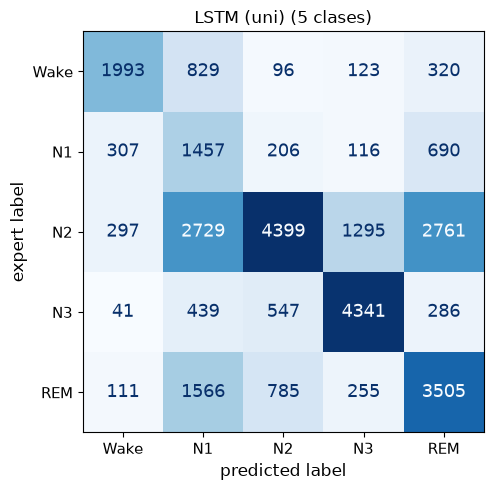

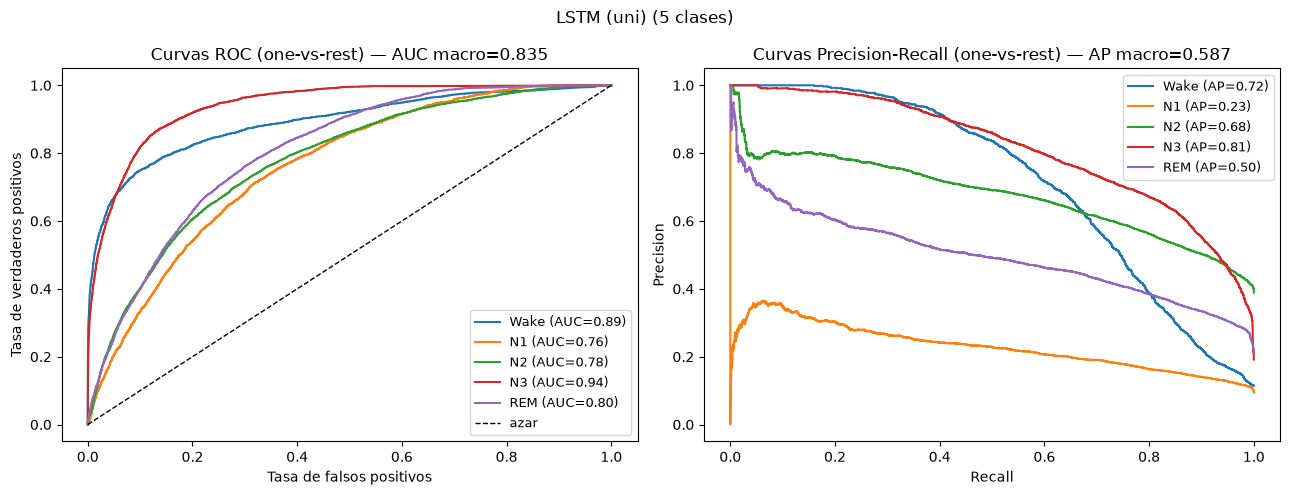


===== LSTM (uni) — 4 clases (test, vs Expert) =====
              precision    recall  f1-score   support

        Wake     0.7250    0.5930    0.6524      3361
       Light     0.6735    0.6166    0.6438     14257
        Deep     0.7082    0.7678    0.7368      5654
         REM     0.4635    0.5633    0.5086      6222

    accuracy                         0.6317     29494
   macro avg     0.6425    0.6352    0.6354     29494
weighted avg     0.6417    0.6317    0.6341     29494

Cohen's Kappa:  0.4595
F1 macro:       0.6354
F1 micro:       0.6317
Accuracy:       0.6317


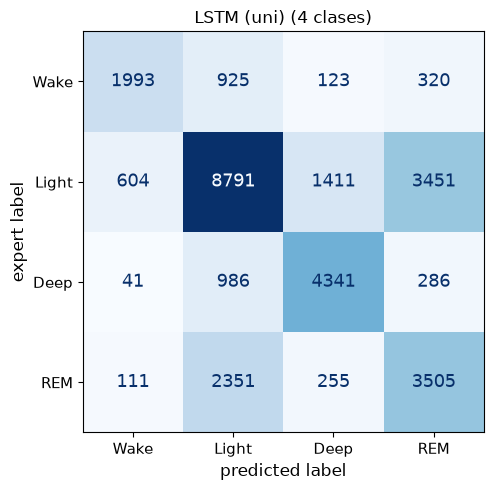

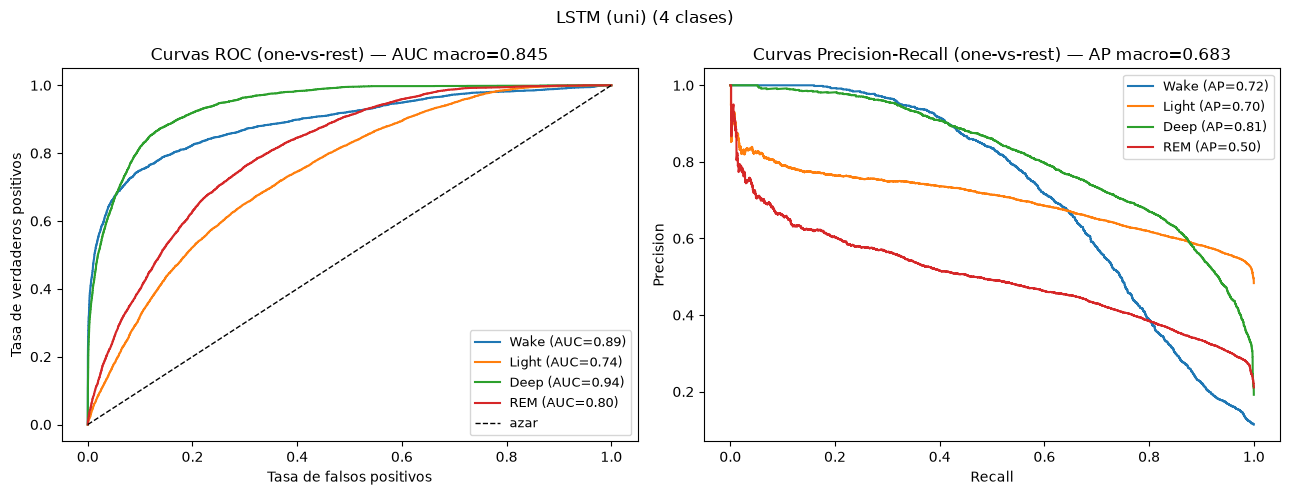

In [7]:
views = [
    ('5 clases', STAGE_NAMES, lambda tm: (tm['y_true'], tm['y_pred'], tm['y_score'])),
    ('4 clases', COLLAPSE_4_NAMES, lambda tm: (collapse4_labels(tm['y_true']),
                                               collapse4_labels(tm['y_pred']),
                                               collapse4_scores(tm['y_score']))),
]
for name, tm in [('BiLSTM', test_bi), ('LSTM (uni)', test_uni)]:
    for view_name, class_names, get in views:
        yt, yp, ys = get(tm)
        print()  # separador
        header = f'===== {name} — {view_name} (test, vs Expert) ====='
        print_metrics(yt, yp, class_names=class_names, name=header)
        plot_confusion(yt, yp, class_names=class_names,
                       title=f'{name} ({view_name})')
        plt.show()
        roc_pr_curves(yt, ys, class_names=class_names,
                      title=f'{name} ({view_name})')
        plt.show()

## 6. Conclusión

La comparación aísla el efecto de la **bidireccionalidad**: ambos modelos comparten
hiperparámetros, split y procedimiento de entrenamiento, y solo difieren en `bidirectional`. La
diferencia de kappa/F1 entre BiLSTM y LSTM unidireccional mide cuánto aporta que cada época vea
el **contexto futuro** de la noche (además del pasado) para la estadificación del sueño.

## 7. Veredicto y conclusión detallada

Comparación sobre el **mismo test set** (29.494 épocas), con **hiperparámetros, split y
procedimiento de entrenamiento idénticos** (deterministas): la única diferencia es
`bidirectional` (True vs False).

### Métricas agregadas (test, vs Expert)

| Vista | Métrica | BiLSTM | LSTM (uni) | Δ (Bi − uni) |
|---|---|---|---|---|
| **5 clases** | Cohen's κ | **0.4630** | 0.4103 | **+0.053** |
| | F1 macro | **0.5673** | 0.5395 | +0.028 |
| | Accuracy | **0.5880** | 0.5321 | +0.056 |
| **4 clases** | Cohen's κ | **0.4907** | 0.4595 | **+0.031** |
| | F1 macro | **0.6500** | 0.6354 | +0.015 |
| | Accuracy | **0.6519** | 0.6317 | +0.020 |

El BiLSTM gana en **todas** las métricas agregadas, en las dos vistas. La ventaja es **mayor en
5 clases** (κ +0.053) que en 4 (κ +0.031): el contexto futuro ayuda sobre todo en las
distinciones finas que se colapsan al pasar a 4 clases.

### Dónde está la diferencia (F1 por clase, 5 clases)

La ventaja **no está repartida**: se concentra casi entera en **N2**.

| Clase | F1 BiLSTM | F1 uni | Comentario |
|---|---|---|---|
| Wake | 0.649 | 0.652 | empate (uni marginalmente mejor) |
| N1 | 0.297 | 0.298 | empate — clase difícil para ambos |
| **N2** | **0.598** | **0.502** | **recall 0.523 vs 0.383: la brecha real** |
| N3 | 0.728 | 0.737 | uni un poco mejor |
| REM | 0.564 | 0.509 | BiLSTM mejor |

Patrón clave: la **LSTM unidireccional se "come" mucho N2 clasificándolo como N1** — el recall
de N1 se le dispara a 0.525 pero con precisión 0.207 (predice N1 espuriamente), mientras el
recall de N2 se desploma a 0.383. El BiLSTM, al ver hacia adelante, confirma la estabilidad de
N2 (que se sostiene por lo que viene *después*) y no lo confunde con transiciones N1. Como N2 es
la clase mayoritaria (11.481 de 29.494 épocas), esa corrección explica casi todo el salto en
accuracy y κ.

### Veredicto

**Gana el BiLSTM, y la mejora es coherente, no ruido.** Con todo lo demás fijo, la
bidireccionalidad aporta **+0.05 de κ y +5.6 pp de accuracy en 5 clases**. El mecanismo es
interpretable: el contexto **futuro** desambigua principalmente **N2 vs N1/transiciones** (y
ayuda algo en REM), justo donde la estadificación del sueño depende de *hacia dónde va* la noche,
no solo de dónde viene.

Matiz honesto: en las clases donde el futuro aporta poco (Wake, N3, y N1 que es intrínsecamente
difícil) las dos versiones empatan o la unidireccional es incluso un pelo mejor. El BiLSTM **no
domina en todo**: concentra su ventaja en N2/REM, pero por el peso de N2 eso alcanza para ganar
claramente en el agregado. La ablación **confirma que la bidireccionalidad del modelo principal
está justificada**.